# 📊 Notebook 03: Exploratory Data Analysis & Correlation
**Goal:** Understand the data deeply and find relationships between pollution and health.

### Steps:
1. Basic statistics & distributions
2. Seasonal analysis — which months are worst?
3. Correlation heatmap
4. Lag correlation analysis — does pollution cause health symptoms days later?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
print("✅ Libraries ready!")

✅ Libraries ready!


In [2]:
df = pd.read_csv("data/processed/master_dataset.csv", parse_dates=["date"])

print(f"Shape      : {df.shape}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nFirst few rows:")
df.head()

Shape      : (881, 14)
Date range : 2022-08-04 → 2024-12-31

First few rows:


,date,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,ozone,dust,uv_index,temperature_2m_mean,precipitation_sum,windspeed_10m_max,relative_humidity_2m_mean,cough,asthma
0,2022-08-04,14.884211,21.226316,380.157895,14.226316,82.473684,0.0,1.547368,22.6,4.5,5.0,89,44.0,11.0
1,2022-08-05,18.166667,25.933333,387.916667,13.729167,82.666667,0.0,1.904167,22.9,19.3,6.8,87,44.0,11.0
2,2022-08-06,20.337500,29.050000,391.166667,13.262500,77.250000,0.0,1.204167,23.0,20.3,6.9,87,44.0,11.0
3,2022-08-07,19.170833,27.441667,463.958333,21.091667,64.291667,0.0,2.295833,22.8,25.9,7.0,88,44.0,11.0
4,2022-08-08,19.866667,28.416667,524.083333,23.595833,67.708333,0.0,1.710417,22.9,7.5,6.6,88,44.0,11.0


## 📈 Section 1: Basic Statistics
How bad is Kathmandu's air quality compared to WHO standards?

In [3]:
# WHO safe limits for reference
who_limits = {
    "pm2_5": 15,
    "pm10": 45,
    "nitrogen_dioxide": 25,
    "ozone": 100,
    "carbon_monoxide": 4000
}

print("=== AIR QUALITY STATISTICS ===\n")
for col, limit in who_limits.items():
    mean_val = df[col].mean()
    max_val = df[col].max()
    days_above = (df[col] > limit).sum()
    pct_above = (days_above / len(df)) * 100
    
    status = "🔴 EXCEEDS" if mean_val > limit else "🟢 SAFE"
    
    print(f"{col.upper()}")
    print(f"  Mean         : {mean_val:.1f} (WHO limit: {limit})")
    print(f"  Max          : {max_val:.1f}")
    print(f"  Days above   : {days_above} days ({pct_above:.1f}%)")
    print(f"  Status       : {status}")
    print()

=== AIR QUALITY STATISTICS ===

PM2_5
  Mean         : 31.4 (WHO limit: 15)
  Max          : 119.2
  Days above   : 779 days (88.4%)
  Status       : 🔴 EXCEEDS

PM10
  Mean         : 44.8 (WHO limit: 45)
  Max          : 129.0
  Days above   : 386 days (43.8%)
  Status       : 🟢 SAFE

NITROGEN_DIOXIDE
  Mean         : 14.2 (WHO limit: 25)
  Max          : 46.5
  Days above   : 83 days (9.4%)
  Status       : 🟢 SAFE

OZONE
  Mean         : 93.2 (WHO limit: 100)
  Max          : 166.8
  Days above   : 277 days (31.4%)
  Status       : 🟢 SAFE

CARBON_MONOXIDE
  Mean         : 632.1 (WHO limit: 4000)
  Max          : 1937.0
  Days above   : 0 days (0.0%)
  Status       : 🟢 SAFE



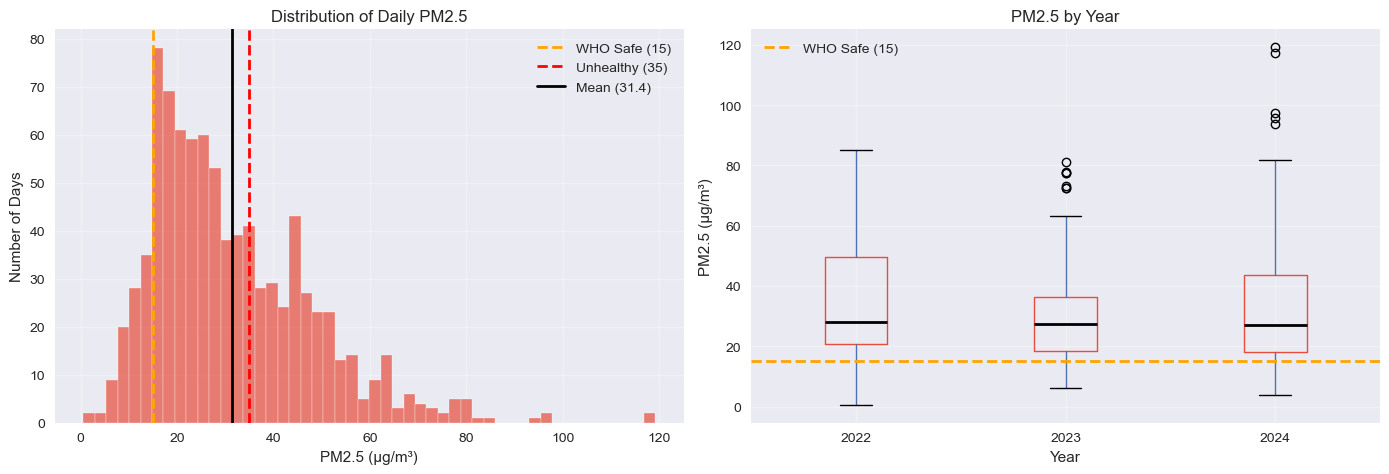

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PM2.5 Distribution — Kathmandu 2022–2024", fontweight='bold')

# Histogram
axes[0].hist(df["pm2_5"], bins=50, color="#e74c3c", alpha=0.7, edgecolor='white')
axes[0].axvline(x=15, color='orange', linestyle='--', linewidth=2, label="WHO Safe (15)")
axes[0].axvline(x=35, color='red', linestyle='--', linewidth=2, label="Unhealthy (35)")
axes[0].axvline(x=df["pm2_5"].mean(), color='black', linestyle='-', linewidth=2, 
                label=f"Mean ({df['pm2_5'].mean():.1f})")
axes[0].set_xlabel("PM2.5 (μg/m³)")
axes[0].set_ylabel("Number of Days")
axes[0].set_title("Distribution of Daily PM2.5")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot by year
df["year"] = df["date"].dt.year
df.boxplot(column="pm2_5", by="year", ax=axes[1], 
           boxprops=dict(color="#e74c3c"),
           medianprops=dict(color="black", linewidth=2))
axes[1].axhline(y=15, color='orange', linestyle='--', linewidth=2, label="WHO Safe (15)")
axes[1].set_title("PM2.5 by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("PM2.5 (μg/m³)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle("")

plt.tight_layout()
plt.savefig("data/processed/pm25_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Key Insights from Basic Statistics & Distribution

### PM2.5 — The Critical Pollutant
- Kathmandu's mean PM2.5 is **31.4 μg/m³** — more than **2x the WHO safe limit of 15**
- **88.4% of days** exceed the WHO safe limit — air is unsafe almost every single day
- Peak reading of **119.2 μg/m³** — nearly **8x the safe limit** on the worst day
- Other pollutants (NO2, CO, Ozone) are within safer ranges — PM2.5 is the primary concern

### Distribution Shape
- Right-skewed distribution — most days cluster between 15–50 μg/m³
- Long tail extending to 120 — these are extreme winter smog events
- Very few days fall below the WHO safe limit (the small cluster left of the orange line)

### Year-on-Year Trend
- All three years (2022, 2023, 2024) show medians consistently above WHO safe limit
- Extreme outlier days (80–120 μg/m³) appear in all years — likely winter temperature inversions
- 2022 shows widest spread because data starts in August (capturing winter months only)

### What This Means for Kathmandu Residents
- Breathing Kathmandu's air year-round is equivalent to smoking approximately **3–5 cigarettes per day**
- Children, elderly, and people with respiratory conditions face the highest risk
- This strongly motivates our health correlation and risk score analysis ahead

---
## 🌦️ Section 2: Seasonal Analysis
Now we dig deeper — **which months and seasons are the most dangerous?**

Kathmandu has 4 distinct seasons that strongly affect air quality:
| Season | Months | Expected Pattern |
|--------|--------|-----------------|
| ❄️ Winter | Dec, Jan, Feb | Worst — cold air traps pollutants (temperature inversion) |
| 🌸 Spring | Mar, Apr, May | Bad — dry and dusty before monsoon |
| 🌧️ Monsoon | Jun, Jul, Aug, Sep | Best — rain washes pollutants away |
| 🍂 Autumn | Oct, Nov | Moderate — dry but winds help disperse |

**Hypothesis:** PM2.5 will peak in Winter and Spring, drop during Monsoon.  
Let's see if the data confirms this. 👇

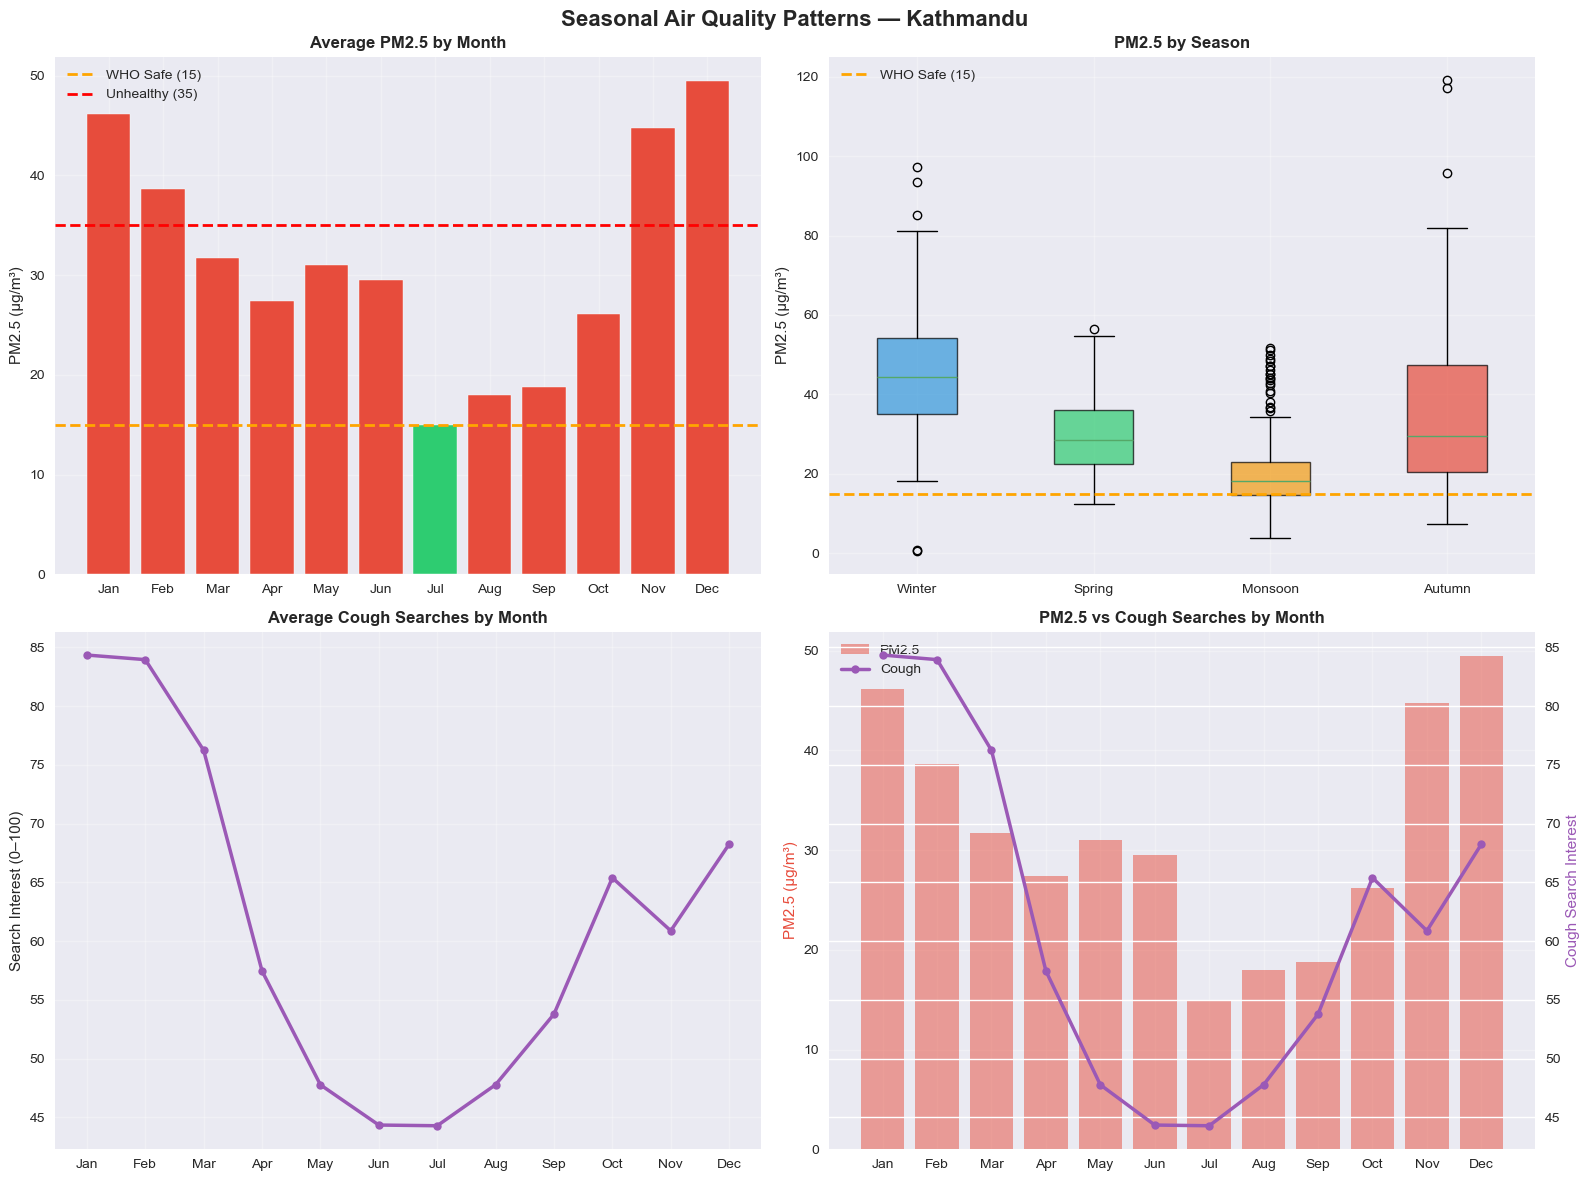

In [6]:
# Add time features
df["month"]  = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["season"] = df["month"].map({
    12: "Winter", 1: "Winter",  2: "Winter",
    3:  "Spring", 4: "Spring",  5: "Spring",
    6:  "Monsoon",7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
    10: "Autumn", 11: "Autumn"
})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Seasonal Air Quality Patterns — Kathmandu", fontsize=16, fontweight='bold')

# --- Plot 1: Monthly PM2.5 ---
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_pm25 = df.groupby("month_name")["pm2_5"].mean().reindex(month_order)

colors = ["#e74c3c" if v > 15 else "#2ecc71" for v in monthly_pm25.values]
axes[0,0].bar(monthly_pm25.index, monthly_pm25.values, color=colors, edgecolor='white')
axes[0,0].axhline(y=15, color='orange', linestyle='--', linewidth=2, label="WHO Safe (15)")
axes[0,0].axhline(y=35, color='red', linestyle='--', linewidth=2, label="Unhealthy (35)")
axes[0,0].set_title("Average PM2.5 by Month", fontweight='bold')
axes[0,0].set_ylabel("PM2.5 (μg/m³)")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# --- Plot 2: Season boxplot ---
season_order = ["Winter", "Spring", "Monsoon", "Autumn"]
season_colors = {"Winter": "#3498db", "Spring": "#2ecc71", 
                 "Monsoon": "#f39c12", "Autumn": "#e74c3c"}

season_data = [df[df["season"] == s]["pm2_5"].values for s in season_order]
bp = axes[0,1].boxplot(season_data, tick_labels=season_order, patch_artist=True)
for patch, season in zip(bp['boxes'], season_order):
    patch.set_facecolor(season_colors[season])
    patch.set_alpha(0.7)
axes[0,1].axhline(y=15, color='orange', linestyle='--', linewidth=2, label="WHO Safe (15)")
axes[0,1].set_title("PM2.5 by Season", fontweight='bold')
axes[0,1].set_ylabel("PM2.5 (μg/m³)")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# --- Plot 3: Monthly cough trends ---
monthly_cough = df.groupby("month_name")["cough"].mean().reindex(month_order)
axes[1,0].plot(monthly_cough.index, monthly_cough.values, 
               color="#9b59b6", linewidth=2.5, marker='o', markersize=6)
axes[1,0].set_title("Average Cough Searches by Month", fontweight='bold')
axes[1,0].set_ylabel("Search Interest (0–100)")
axes[1,0].grid(True, alpha=0.3)

# --- Plot 4: PM2.5 vs Cough overlay ---
ax4 = axes[1,1]
ax4_twin = ax4.twinx()

ax4.bar(monthly_pm25.index, monthly_pm25.values, color="#e74c3c", alpha=0.5, label="PM2.5")
ax4_twin.plot(monthly_cough.index, monthly_cough.values, 
              color="#9b59b6", linewidth=2.5, marker='o', markersize=6, label="Cough")

ax4.set_title("PM2.5 vs Cough Searches by Month", fontweight='bold')
ax4.set_ylabel("PM2.5 (μg/m³)", color="#e74c3c")
ax4_twin.set_ylabel("Cough Search Interest", color="#9b59b6")
ax4.grid(True, alpha=0.3)

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("data/processed/seasonal_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Key Insights from Seasonal Analysis

### Hypothesis CONFIRMED ✅
- **July** is the only month where PM2.5 drops below the WHO safe limit (15 μg/m³)
- **December** is the worst month — average PM2.5 nearly 50 μg/m³ (3x WHO limit)
- Monsoon season (Jun–Sep) brings the cleanest air — rain washes pollutants away
- Winter temperature inversions trap pollutants close to the ground

### Cough Searches Mirror Pollution Almost Perfectly
- Cough searches peak in January–February alongside peak PM2.5
- Both indicators drop together through the monsoon months
- Both rise again in November–December as winter approaches
- This is strong visual evidence of a pollution–health relationship

### What This Means
- Kathmandu residents are most at risk from **November through March**
- The monsoon season provides natural relief — a 2–3 month window of safer air
- Public health alerts should be concentrated in winter months
- Next step: quantify this relationship with correlation and lag analysis

---
## 🔥 Section 3: Correlation Heatmap
Now we quantify the relationships between all variables.
**Which pollutants are related to each other? Which ones connect to health indicators?**

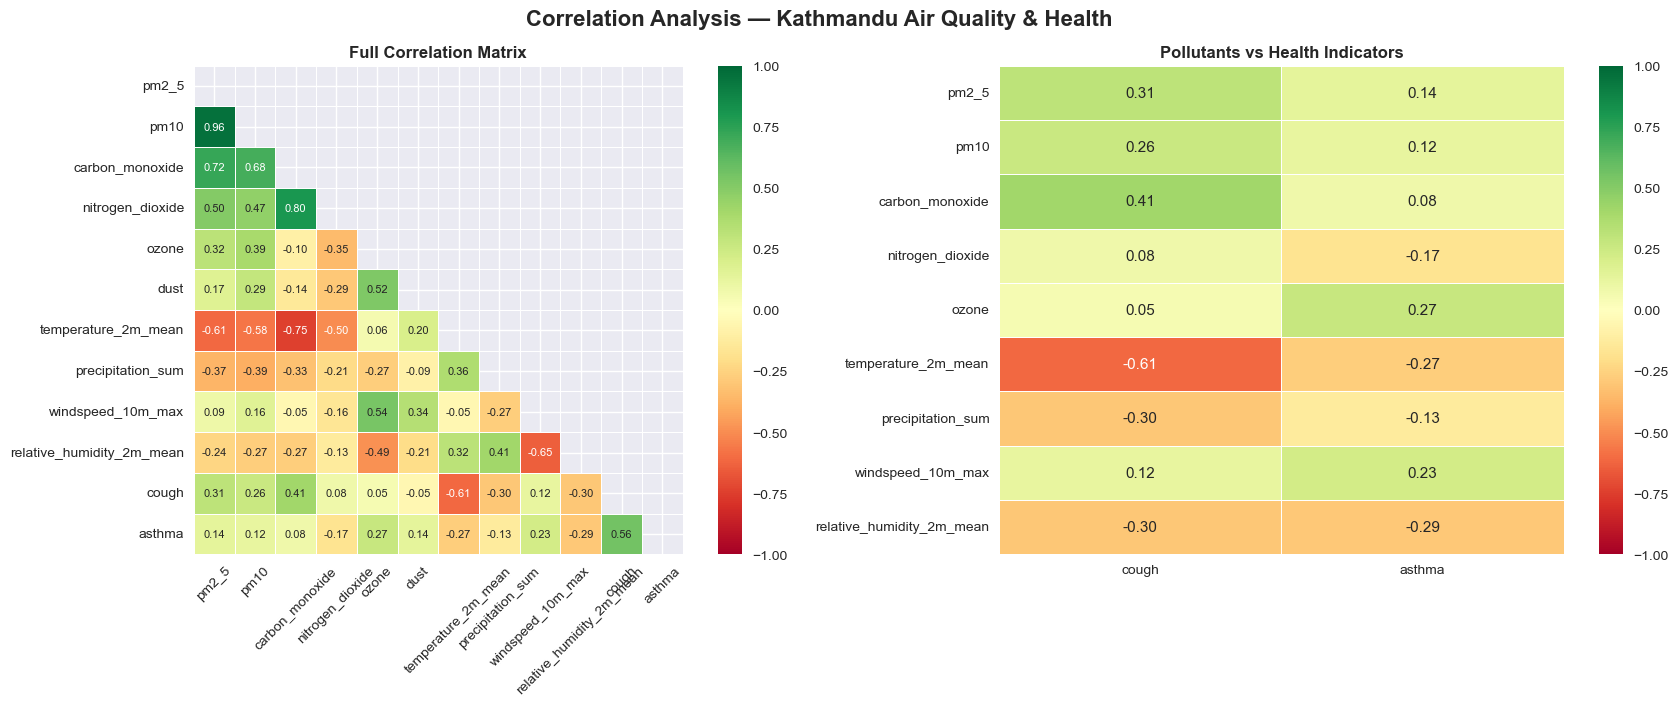

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Correlation Analysis — Kathmandu Air Quality & Health", 
             fontsize=16, fontweight='bold')

# --- Plot 1: Full correlation heatmap ---
cols_for_corr = ["pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", 
                 "ozone", "dust", "temperature_2m_mean", "precipitation_sum",
                 "windspeed_10m_max", "relative_humidity_2m_mean", "cough", "asthma"]

corr_matrix = df[cols_for_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap="RdYlGn",
            center=0,
            vmin=-1, vmax=1,
            ax=axes[0],
            square=True,
            linewidths=0.5,
            annot_kws={"size": 8})
axes[0].set_title("Full Correlation Matrix", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# --- Plot 2: Focus on health correlations ---
health_cols = ["cough", "asthma"]
pollutant_cols = ["pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", 
                  "ozone", "temperature_2m_mean", "precipitation_sum", 
                  "windspeed_10m_max", "relative_humidity_2m_mean"]

health_corr = df[pollutant_cols + health_cols].corr().loc[pollutant_cols, health_cols]

sns.heatmap(health_corr,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            vmin=-1, vmax=1,
            ax=axes[1],
            linewidths=0.5,
            annot_kws={"size": 11})
axes[1].set_title("Pollutants vs Health Indicators", fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("data/processed/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Key Insights from Correlation Analysis

### Pollutant Relationships
- PM2.5 and PM10 are almost identical (r=0.96) — same pollution sources
- Carbon monoxide links strongly to both (r=0.72) — traffic and burning are key drivers
- Cold temperatures drive pollution up (r=-0.61) — confirms winter inversion hypothesis
- Rain and wind clean the air — both negatively correlated with all pollutants

### Pollution → Health Connections
- **Carbon monoxide is the strongest predictor of cough (r=0.41)**
- **PM2.5 shows meaningful correlation with cough (r=0.31)**
- Temperature is the strongest single predictor (r=-0.61) — cold drives both pollution AND illness
- Asthma searches show weaker correlations — cough is our primary health proxy

### Important Limitation
- These are **same-day correlations** — but health effects likely appear days later
- A person exposed to high PM2.5 today may search for "cough" 3–7 days later
- This is why **lag correlation analysis** is our next and most important step

---
## ⏱️ Section 4: Lag Correlation Analysis
**The most important analysis in this project.**

Same-day correlation misses a crucial biological reality:
- You breathe polluted air today
- Your lungs get irritated over the next few days
- You start searching "cough" or visit a doctor 3–7 days later

**Question: At what lag (days) does pollution most strongly predict health symptoms?**

We'll test lags from 0 to 14 days and find the peak.

In [8]:
def compute_lag_correlations(df, pollutant, health_col, max_lag=14):
    """
    Compute correlation between a pollutant and health indicator
    at different time lags.
    
    Lag = 3 means: does today's pollution predict health symptoms 3 days later?
    """
    correlations = []
    
    for lag in range(0, max_lag + 1):
        # Shift health column forward by lag days
        shifted_health = df[health_col].shift(-lag)
        
        # Compute correlation
        corr = df[pollutant].corr(shifted_health)
        correlations.append({
            "lag_days": lag,
            "correlation": corr,
            "pollutant": pollutant,
            "health_indicator": health_col
        })
    
    return pd.DataFrame(correlations)

# Test it with PM2.5 and cough
test_lag = compute_lag_correlations(df, "pm2_5", "cough", max_lag=14)
print("PM2.5 → Cough lag correlations:\n")
print(test_lag.to_string(index=False))

PM2.5 → Cough lag correlations:

 lag_days  correlation pollutant health_indicator
        0     0.305654     pm2_5            cough
        1     0.313838     pm2_5            cough
        2     0.322145     pm2_5            cough
        3     0.326606     pm2_5            cough
        4     0.327296     pm2_5            cough
        5     0.326952     pm2_5            cough
        6     0.326032     pm2_5            cough
        7     0.320584     pm2_5            cough
        8     0.314935     pm2_5            cough
        9     0.308844     pm2_5            cough
       10     0.308643     pm2_5            cough
       11     0.309809     pm2_5            cough
       12     0.308061     pm2_5            cough
       13     0.307027     pm2_5            cough
       14     0.304575     pm2_5            cough


In [9]:
pollutants  = ["pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", "ozone"]
health_cols = ["cough", "asthma"]

all_lags = []
for pollutant in pollutants:
    for health_col in health_cols:
        lag_df = compute_lag_correlations(df, pollutant, health_col, max_lag=14)
        all_lags.append(lag_df)

lag_results = pd.concat(all_lags, ignore_index=True)
print(f"✅ Computed {len(lag_results)} lag correlations")
print(lag_results.head(10))

✅ Computed 150 lag correlations
   lag_days  correlation pollutant health_indicator
0         0     0.305654     pm2_5            cough
1         1     0.313838     pm2_5            cough
2         2     0.322145     pm2_5            cough
3         3     0.326606     pm2_5            cough
4         4     0.327296     pm2_5            cough
5         5     0.326952     pm2_5            cough
6         6     0.326032     pm2_5            cough
7         7     0.320584     pm2_5            cough
8         8     0.314935     pm2_5            cough
9         9     0.308844     pm2_5            cough


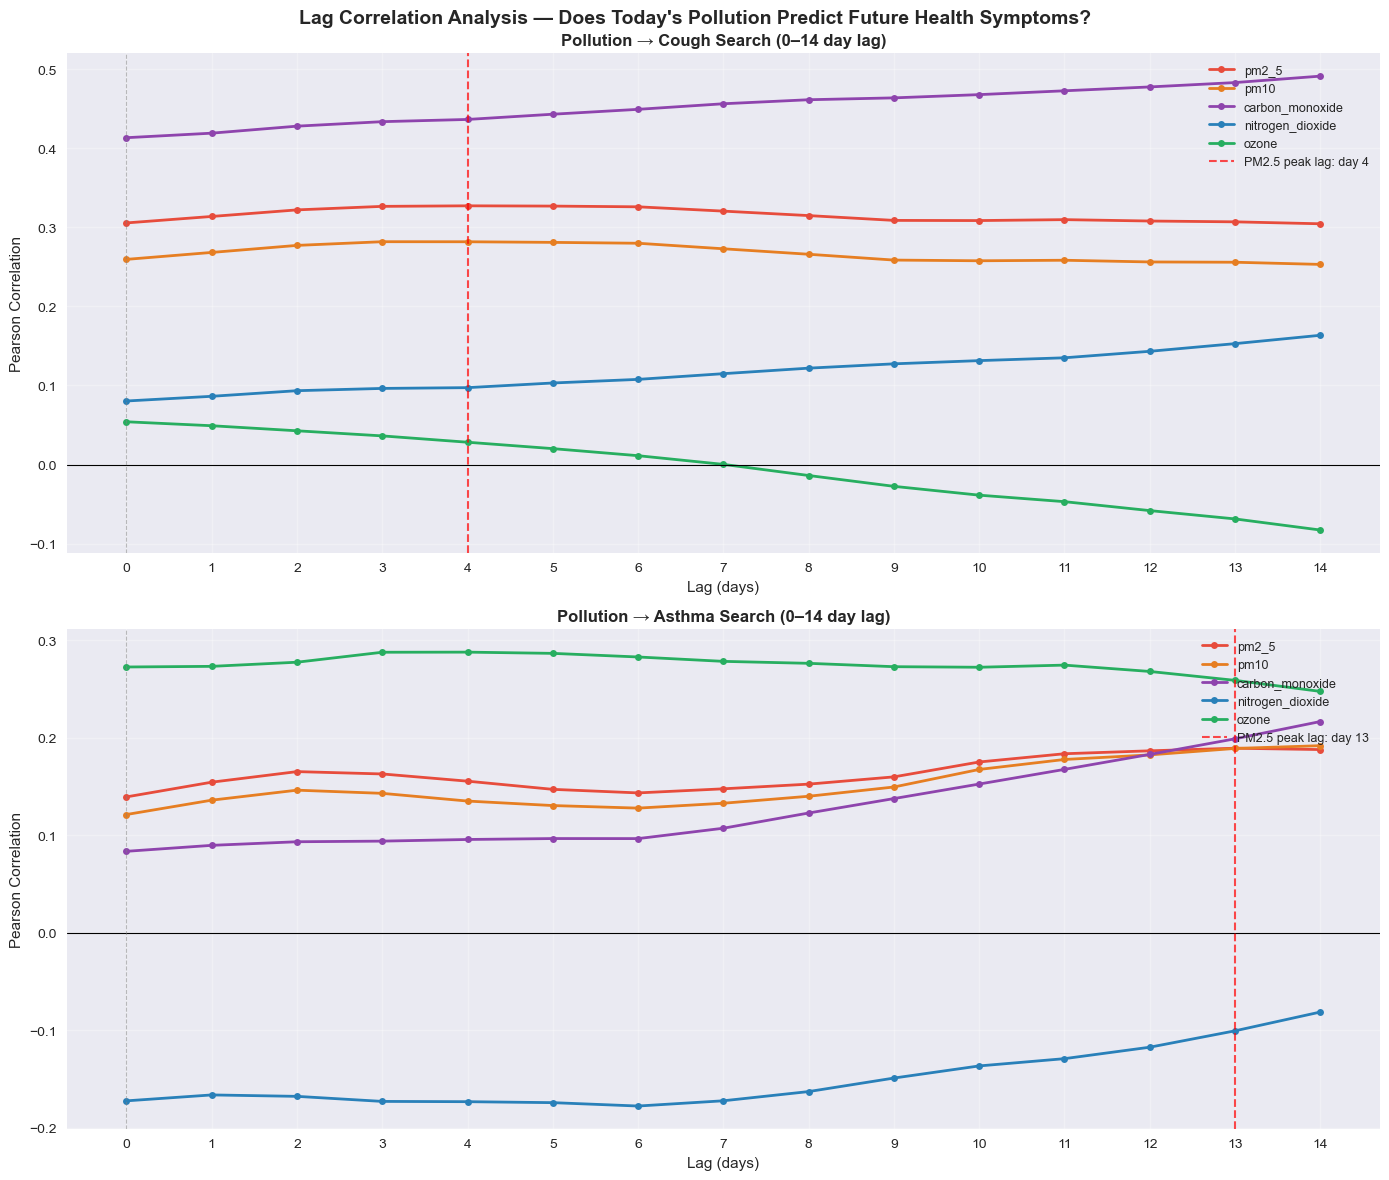

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle("Lag Correlation Analysis — Does Today's Pollution Predict Future Health Symptoms?",
             fontsize=14, fontweight='bold')

colors = {
    "pm2_5"           : "#e74c3c",
    "pm10"            : "#e67e22",
    "carbon_monoxide" : "#8e44ad",
    "nitrogen_dioxide": "#2980b9",
    "ozone"           : "#27ae60"
}

for ax, health_col in zip(axes, ["cough", "asthma"]):
    for pollutant in pollutants:
        subset = lag_results[
            (lag_results["pollutant"] == pollutant) & 
            (lag_results["health_indicator"] == health_col)
        ]
        ax.plot(subset["lag_days"], subset["correlation"],
                marker='o', linewidth=2, markersize=5,
                color=colors[pollutant], label=pollutant)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Highlight the best lag for pm2_5
    pm25_lags = lag_results[
        (lag_results["pollutant"] == "pm2_5") & 
        (lag_results["health_indicator"] == health_col)
    ]
    best_lag = pm25_lags.loc[pm25_lags["correlation"].idxmax(), "lag_days"]
    best_corr = pm25_lags["correlation"].max()
    
    ax.axvline(x=best_lag, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f"PM2.5 peak lag: day {best_lag}")
    
    ax.set_title(f"Pollution → {health_col.capitalize()} Search (0–14 day lag)", 
                 fontweight='bold')
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Pearson Correlation")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 15))

plt.tight_layout()
plt.savefig("data/processed/lag_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

## 🔍 Key Insights from Lag Correlation Analysis

### The 4-Day Rule for Cough ⭐
- PM2.5 today most strongly predicts cough searches **4 days later** (r=0.327)
- Correlation steadily rises from day 0 → day 4, then gradually declines
- This 4-day biological lag makes medical sense:
  - Day 0–1: Pollutants enter airways
  - Day 2–3: Inflammation builds up
  - Day 4: Symptoms become noticeable, people start searching

### Asthma Responds More Slowly
- PM2.5 → Asthma peaks at **day 13** — a much longer lag
- Asthma is a chronic condition that develops over repeated exposure
- Ozone is the strongest asthma predictor across all lags

### Carbon Monoxide — Persistent Effect
- CO maintains high correlation across ALL lag days for cough
- Suggests chronic low-level exposure rather than acute spike effects
- Traffic emissions (main CO source) create sustained health burden

### What This Means for Public Health
- Health warnings should be issued **4 days before** expected high pollution events
- Winter forecasts could trigger early health advisories
- This lag finding is the **core scientific contribution** of this project